In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn import hmm
from hmmlearn.hmm import GaussianHMM
import plotly.express as px
import mlflow
from mlflow.models.signature import infer_signature
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from scipy.stats import wilcoxon
from itertools import combinations
import itertools

In [2]:
file_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/improved_features_data_main/two_class_raw_1s_no.csv'
features = pd.read_csv(file_path)
features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

In [3]:
class_names = ['void', 'non-void']

In [4]:
def generate_confusion_matrix(cnf_matrix, classes, normalize=False, title='Confusion matrix'):
    plt.imshow(cnf_matrix, interpolation='nearest', cmap=plt.get_cmap())
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cnf_matrix.max() / 2.

    for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
        plt.text(j, i, format(cnf_matrix[i, j], fmt), horizontalalignment="center",
                color="black" if cnf_matrix[i, j] > thresh else "yellow")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    return cnf_matrix

In [5]:
def plot_confusion_matrix(predicted_labels_list, y_test_list, strategy_name, exp_name):
    cnf_matrix = confusion_matrix(y_test_list, predicted_labels_list, labels=class_names)
    np.set_printoptions(precision=2)

    # Plot non-normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, title=f'XGBoost - {exp_name}({strategy_name})')
    file_name = f'cv-cm_{exp_name}_{strategy_name}.png'
    plt.savefig(f'/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/XGBoost/2_class/cv-conf-mat/{file_name}')
    plt.show()

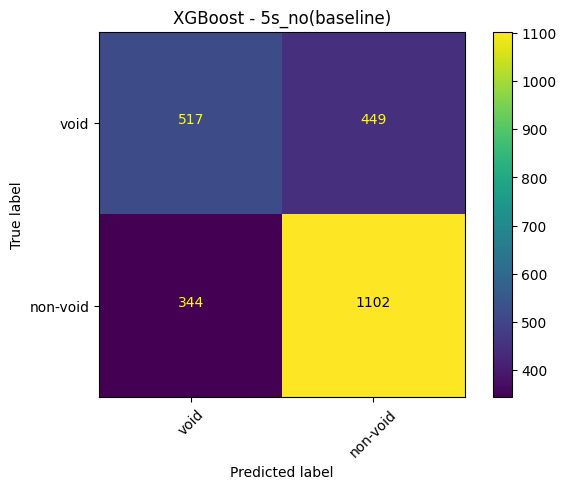

In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]



# Cross-validation setup
gkf = GroupKFold(n_splits=10) 
fold_results = []
        
# For confusion matrix
predicted_targets = np.array([])
actual_targets = np.array([])
        
for fold_num, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X, y, groups)):
    X_train_fold, X_test_fold = X.iloc[train_idx_fold], X.iloc[test_idx_fold]
    y_train_fold, y_test_fold = y.iloc[train_idx_fold], y.iloc[test_idx_fold]
# for fold_num, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X_train, y_train, groups_train)):   
#     X_train_fold, X_test_fold = X_train.iloc[train_idx_fold], X_train.iloc[test_idx_fold]
#     y_train_fold, y_test_fold = y_train.iloc[train_idx_fold], y_train.iloc[test_idx_fold]
    
    # sampler =  SMOTETomek(random_state=42)
    # X_train_fold, y_train_fold = sampler.fit_resample(X_train_fold, y_train_fold)
    
    # Use XGBoost with DEFAULT parameters
    model = XGBClassifier(
        random_state=42,
        eval_metric='logloss',  # Suppress warning
    )
    
    # Encode labels
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train_fold)
    
    # Fit model
    model.fit(X_train_fold, y_train_encoded)
    
    # Predict
    predictions = label_encoder.inverse_transform(model.predict(X_test_fold))
    
    # For confusion matrix
    predicted_targets = np.append(predicted_targets, predictions)
    actual_targets = np.append(actual_targets, y_test_fold)
plot_confusion_matrix(predicted_targets, actual_targets,'baseline', '5s_no')

In [7]:
class_report = classification_report(actual_targets,predicted_targets, labels=class_names)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

        void       0.60      0.54      0.57       966
    non-void       0.71      0.76      0.74      1446

    accuracy                           0.67      2412
   macro avg       0.66      0.65      0.65      2412
weighted avg       0.67      0.67      0.67      2412



### Test

I wish 🤣

In [8]:
# Classification report
y_pred = label_encoder.inverse_transform(model.predict(X_test))
report = classification_report(y_test, y_pred, labels=class_names)

print(report)

              precision    recall  f1-score   support

        void       0.95      0.95      0.95       246
    non-void       0.97      0.97      0.97       396

    accuracy                           0.96       642
   macro avg       0.96      0.96      0.96       642
weighted avg       0.96      0.96      0.96       642



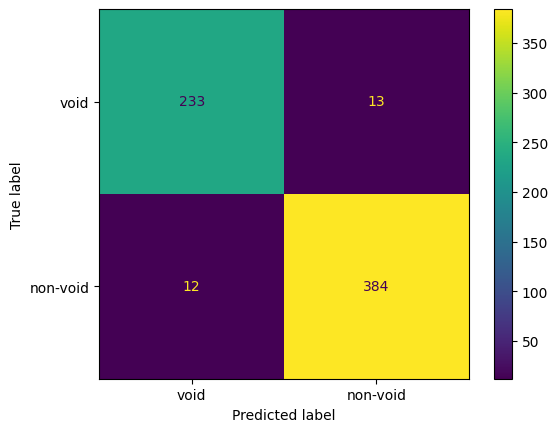

In [9]:
cnf_matrix = confusion_matrix(y_test, y_pred, labels=class_names)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cnf_matrix, display_labels = ['void', 'non-void'])
cm_display.plot()
plt.show()

In [10]:
features

,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,acc_x_min,acc_x_max,acc_x_time_energy,...,gyr_mag_spectral_centroid,gyr_mag_spectral_spread,gyr_mag_spectral_flatness,gyr_mag_peak_frequency_ratio,gyr_mag_hjorth_frequency,gyr_mag_spectral_skewness,gyr_mag_spectral_kurtosis,gyr_mag_snr,label,experiment_id
0,0.840598,0.524760,0.938842,1.134729,5.349532,1.472764,1.287610,-1.100002,4.249530,127.972959,...,5.306330,2.733279,0.051141,0.248079,7.643653,0.771207,6.505756,-4.815822,non-void,1
1,0.816380,0.561207,1.115575,0.848165,3.553001,1.401390,0.719385,-0.289933,3.263068,115.869664,...,3.076435,2.032066,0.019512,0.338830,7.038916,1.899025,12.455712,-2.903304,non-void,1
2,0.892873,0.755155,0.804784,0.245606,1.054752,0.841427,0.060322,0.291806,1.346558,41.771927,...,6.125751,5.084524,0.310876,0.211430,13.267912,1.507646,6.138261,-5.716727,non-void,1
3,0.928689,0.707887,0.720945,0.292908,1.507445,0.778175,0.085795,-0.158125,1.349320,35.727849,...,3.310932,3.995551,0.127136,0.494355,11.415845,2.877557,13.332518,-0.098072,non-void,1
4,0.874944,0.797456,0.588285,0.231525,1.161934,0.632205,0.053604,-0.156841,1.005093,23.581297,...,5.479265,4.786192,0.167407,0.217080,11.995728,1.275285,4.429930,-5.570982,non-void,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2407,0.861280,0.934936,-0.554569,0.075345,0.315175,0.559664,0.005677,-0.690615,-0.375441,18.793424,...,9.459245,8.350250,0.490834,0.195808,15.466796,0.569494,2.001480,-6.135297,non-void,41
2408,0.885975,0.883050,-0.532731,0.070325,0.453110,0.537353,0.004946,-0.799493,-0.346383,17.324900,...,5.109637,6.526572,0.196260,0.535277,13.392340,1.568644,4.447534,0.613839,non-void,41
2409,0.927914,0.874430,-0.264320,0.091840,0.344941,0.279820,0.008435,-0.453147,-0.108205,4.697961,...,4.357160,6.227590,0.204807,0.547673,12.663315,2.161615,7.041075,0.830684,non-void,41
2410,0.914823,0.887964,-0.251440,0.084821,0.408489,0.265361,0.007195,-0.449646,-0.041157,4.224994,...,7.862668,6.931943,0.391093,0.278527,13.572693,1.171952,3.728496,-4.133518,non-void,41


In [11]:
labels = features['label']
print(f'total = {len(labels)}')
print(f'void = {len(labels[labels == 'void'])}')
print(f'non-void = {len(labels[labels == 'non-void'])}')

total = 2412
void = 966
non-void = 1446
